In [138]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})
sns.set_style('whitegrid')

df = pd.read_csv('results/comparison_r_max_sweep.csv')
df['r_max'] = df['classifier'].str.extract(r'r(\d+)').astype(int)
r_vals = sorted(df['r_max'].unique())
print(f'r_max values: {r_vals}, datasets: {df["dataset"].nunique()}')

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
%config InlineBackend.figure_formats = {'png', 'retina'}

r_max values: [np.int64(25), np.int64(50), np.int64(75), np.int64(100), np.int64(125)], datasets: 22


# Ensemble Size variants

In [139]:
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})
sns.set_style('whitegrid')

df = pd.read_csv('results/comparison_ensemble_half.csv')
print(df.columns.tolist())
print(f'Datasets: {df["dataset"].nunique()}')

['classifier', 'dataset', 'fit_time_s_baseline', 'fit_time_s_new', 'fit_time_s_delta', 'predict_time_s_baseline', 'predict_time_s_new', 'predict_time_s_delta', 'predict_time_per_sample_ms_baseline', 'predict_time_per_sample_ms_new', 'predict_time_per_sample_ms_delta', 'peak_fit_mem_mb_baseline', 'peak_fit_mem_mb_new', 'peak_fit_mem_mb_delta', 'accuracy_baseline', 'accuracy_new', 'accuracy_delta', 'balanced_accuracy_baseline', 'balanced_accuracy_new', 'balanced_accuracy_delta', 'train_cv_accuracy_baseline', 'train_cv_accuracy_new', 'train_cv_accuracy_delta', 'dataset_type', 'train_size_bin', 'series_len_bin', 'n_classes_bin', 'n_features_baseline', 'n_features_new']
Datasets: 112


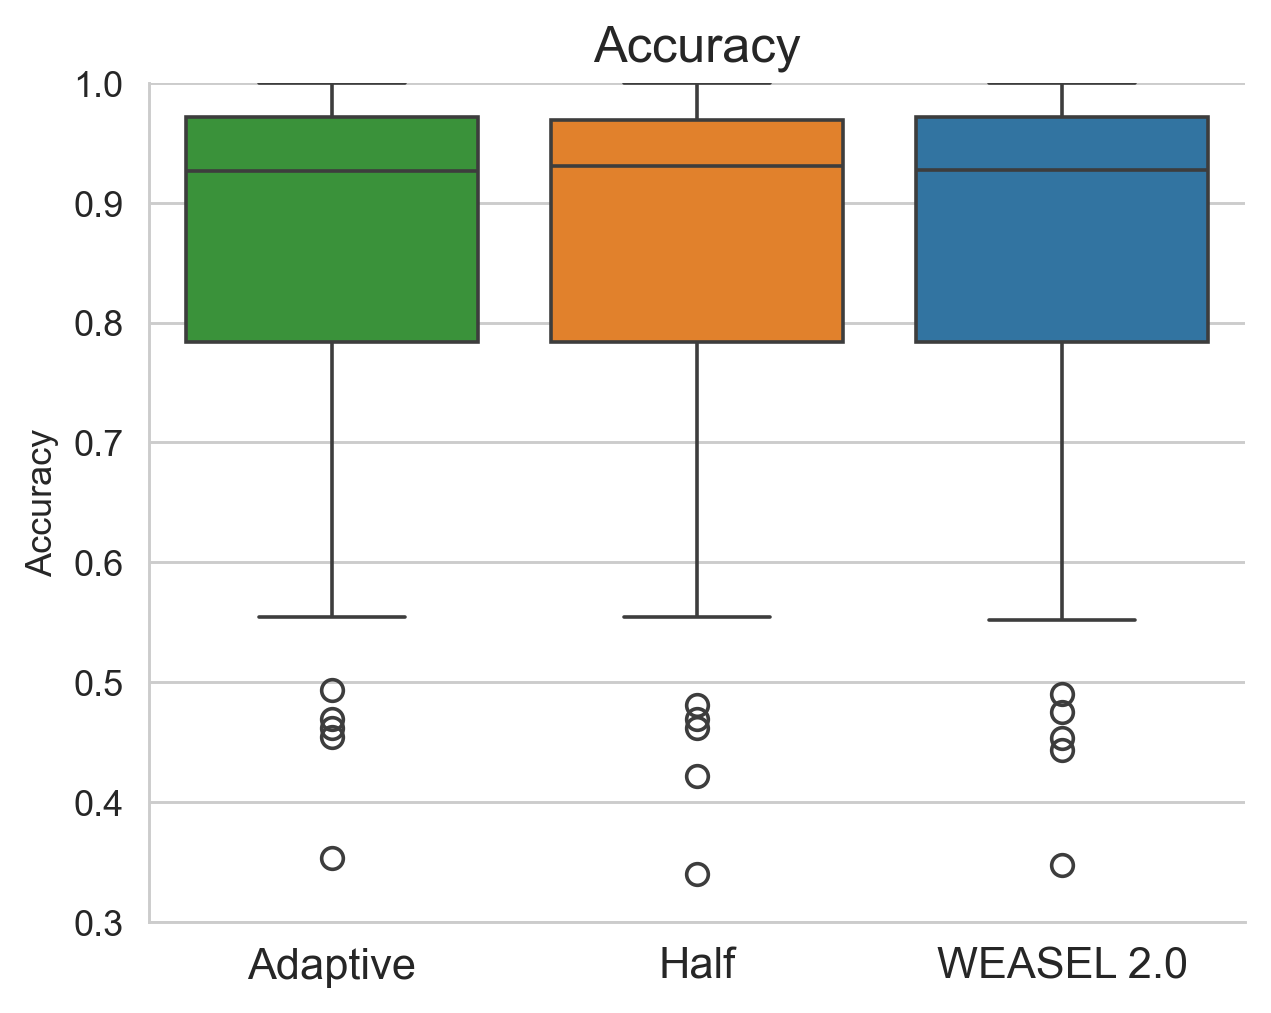

In [146]:
df_half = pd.read_csv('results/comparison_ensemble_half.csv')
df_adaptive = pd.read_csv('results/comparison_adaptive_ensemble.csv')

baseline = df_half[['dataset', 'accuracy_baseline']].copy()
baseline.columns = ['dataset', 'Accuracy']
baseline['Classifier'] = 'WEASEL 2.0'

half = df_half[['dataset', 'accuracy_new']].copy()
half.columns = ['dataset', 'Accuracy']
half['Classifier'] = 'Half'

adaptive = df_adaptive[['dataset', 'accuracy_new']].copy()
adaptive.columns = ['dataset', 'Accuracy']
adaptive['Classifier'] = 'Adaptive'

plot_df = pd.concat([baseline, half, adaptive], ignore_index=True)

order = ['Adaptive', 'Half', 'WEASEL 2.0']

fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(
    y='Accuracy', x='Classifier', data=plot_df, ax=ax,
    order=order, hue='Classifier', legend=False,
)
ax.tick_params(axis='x', labelsize=12)
ax.set_xlabel('')
ax.set_ylim(0.3, 1)
ax.set_title('Accuracy', fontsize=14)
sns.despine()
plt.tight_layout()
plt.show()

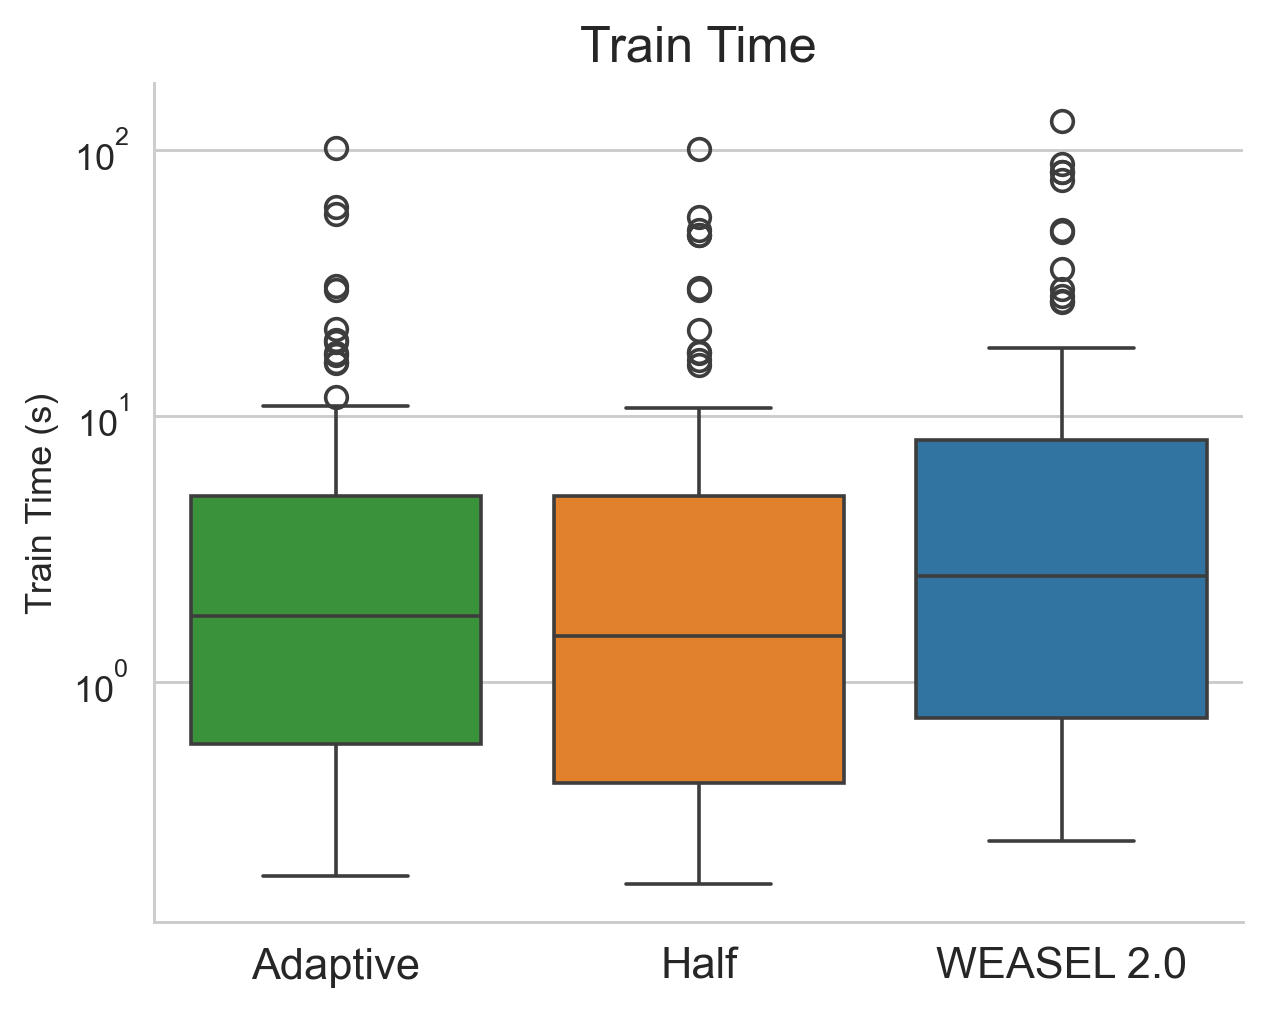

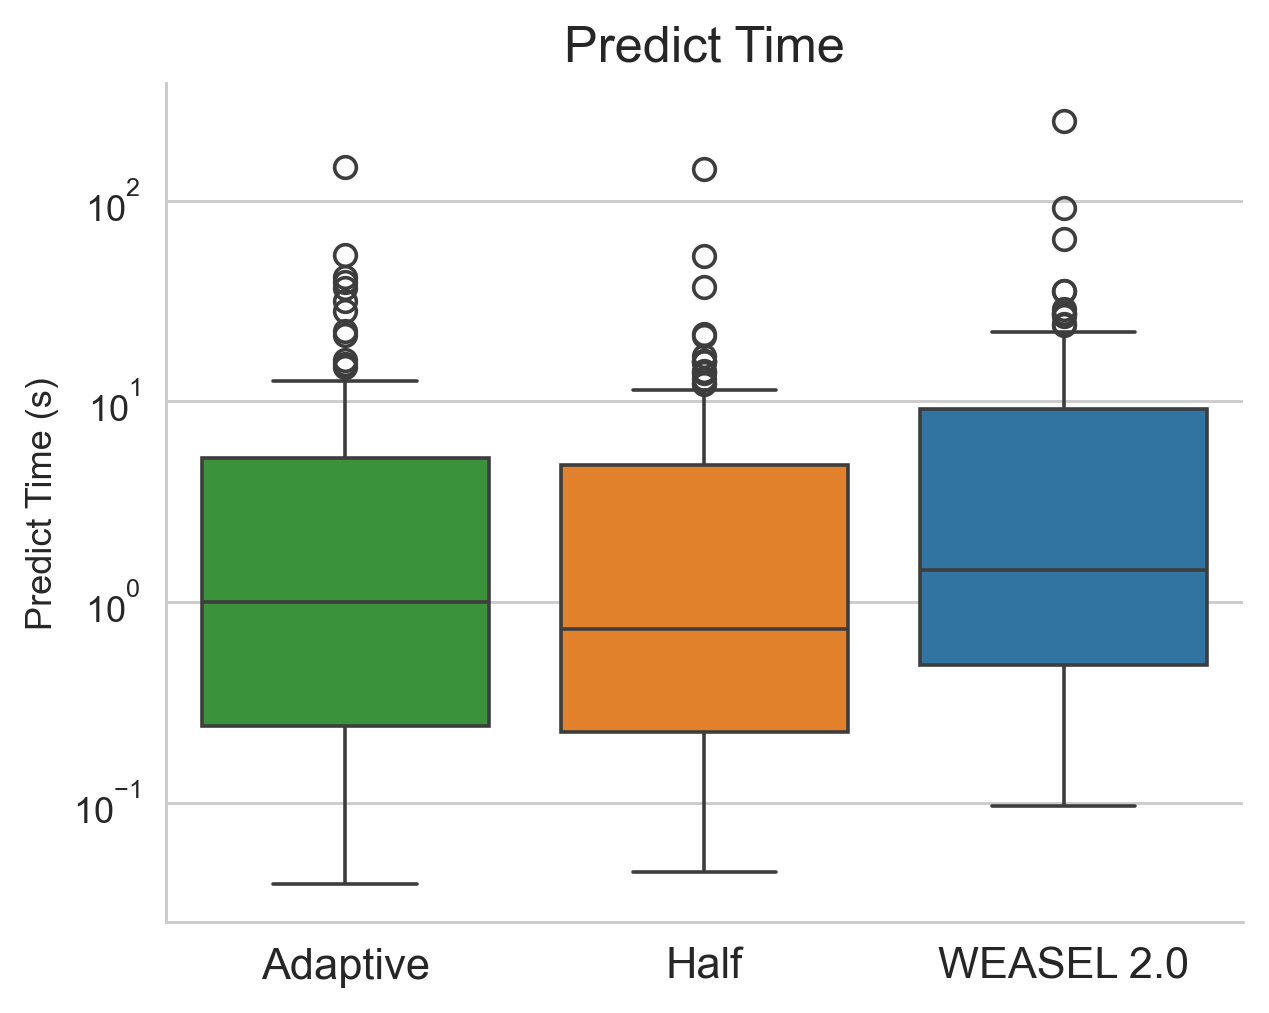

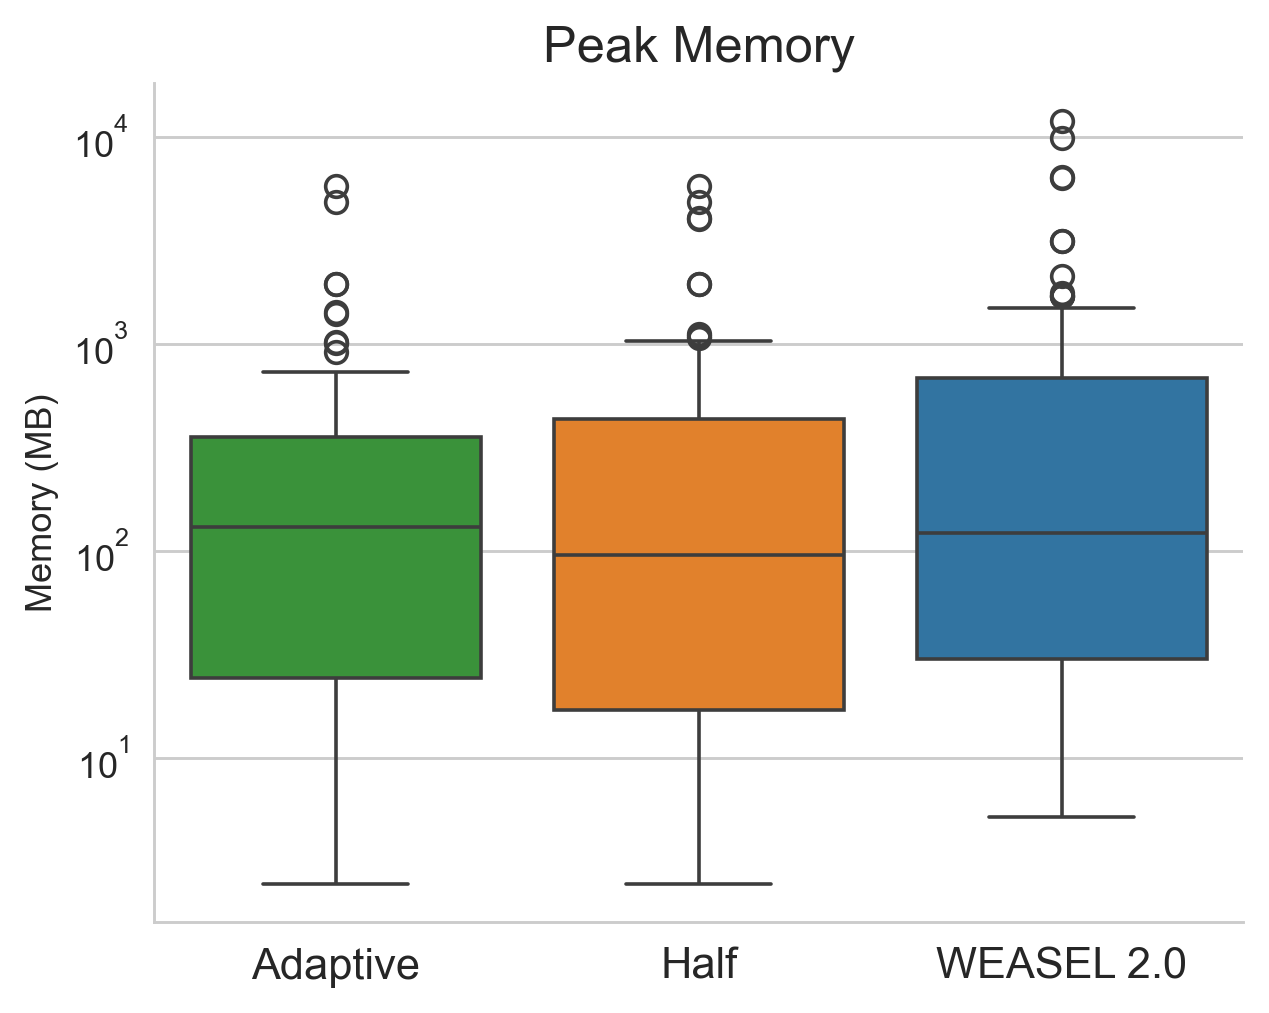

In [147]:
for col_base, col_new, ylabel, title in [
    ('fit_time_s_baseline', 'fit_time_s_new', 'Train Time (s)', 'Train Time'),
    ('predict_time_s_baseline', 'predict_time_s_new', 'Predict Time (s)', 'Predict Time'),
    ('peak_fit_mem_mb_baseline', 'peak_fit_mem_mb_new', 'Memory (MB)', 'Peak Memory'),
]:
    baseline_metric = df_half[['dataset', col_base]].copy()
    baseline_metric.columns = ['dataset', ylabel]
    baseline_metric['Classifier'] = 'WEASEL 2.0'

    half_metric = df_half[['dataset', col_new]].copy()
    half_metric.columns = ['dataset', ylabel]
    half_metric['Classifier'] = 'Half'

    adaptive_metric = df_adaptive[['dataset', col_new]].copy()
    adaptive_metric.columns = ['dataset', ylabel]
    adaptive_metric['Classifier'] = 'Adaptive'

    plot_df_metric = pd.concat([baseline_metric, half_metric, adaptive_metric], ignore_index=True)

    order = ['Adaptive', 'Half', 'WEASEL 2.0']

    fig, ax = plt.subplots(figsize=(5, 4))
    g = sns.boxplot(
        y=ylabel, x='Classifier', data=plot_df_metric, ax=ax,
        order=order, hue='Classifier', legend=False,
    )
    g.set_yscale("log")
    ax.tick_params(axis='x', labelsize=12)
    ax.set_xlabel('')
    ax.set_title(title, fontsize=14)
    sns.despine()
    plt.tight_layout()
    plt.show()

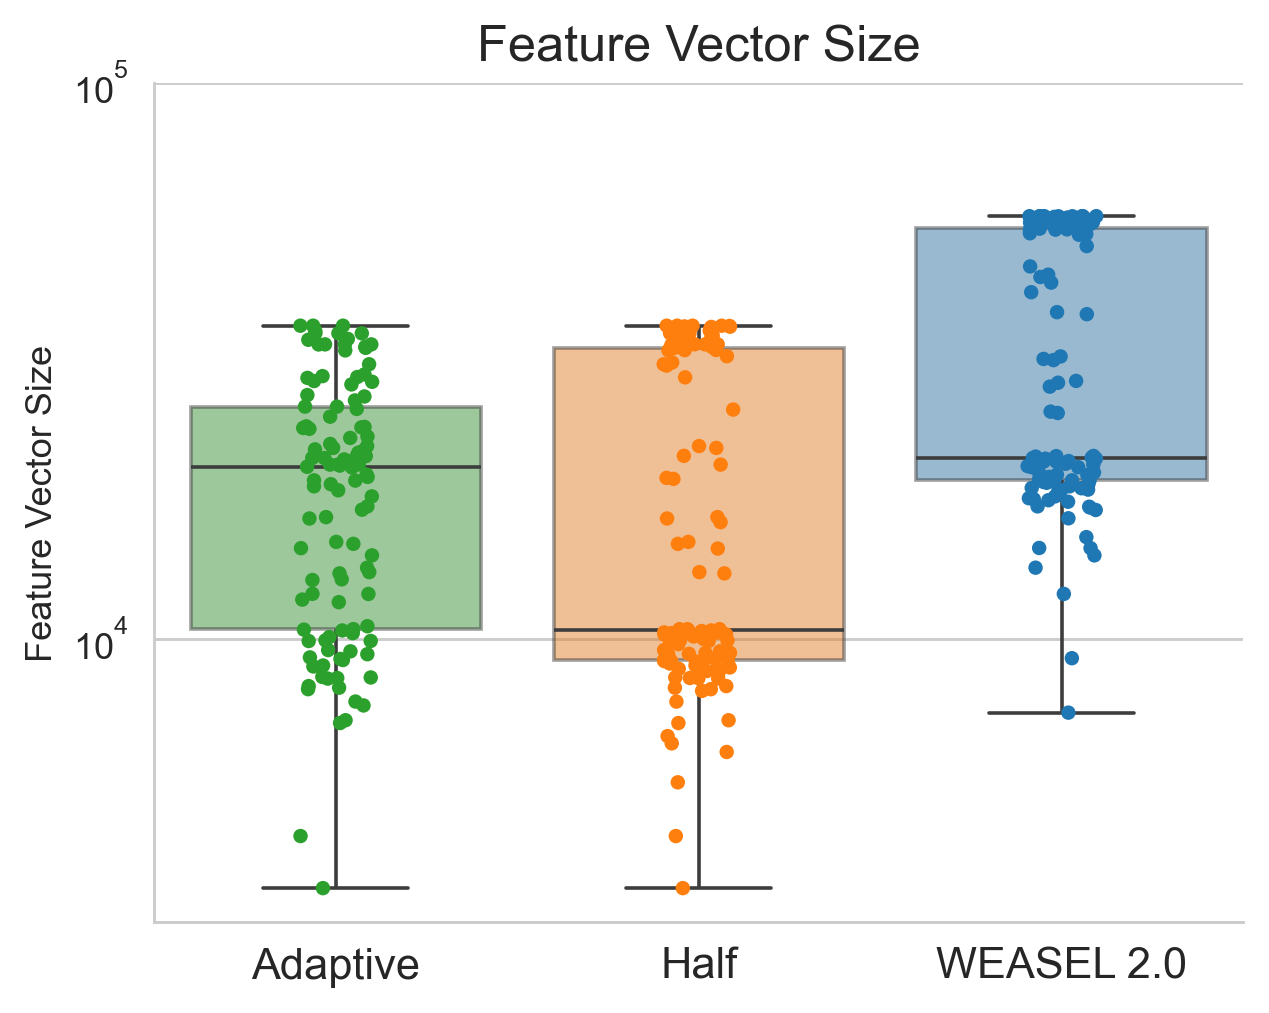

In [148]:
baseline_features = df_half[['dataset', 'n_features_baseline']].copy()
baseline_features.columns = ['dataset', 'Feature Vector Size']
baseline_features['Classifier'] = 'WEASEL 2.0'

half_features = df_half[['dataset', 'n_features_new']].copy()
half_features.columns = ['dataset', 'Feature Vector Size']
half_features['Classifier'] = 'Half'

adaptive_features = df_adaptive[['dataset', 'n_features_new']].copy()
adaptive_features.columns = ['dataset', 'Feature Vector Size']
adaptive_features['Classifier'] = 'Adaptive'

plot_df_features = pd.concat([baseline_features, half_features, adaptive_features], ignore_index=True)

order = ['Adaptive', 'Half', 'WEASEL 2.0']

fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(y='Feature Vector Size', x='Classifier', data=plot_df_features, ax=ax,
            order=order, hue='Classifier', legend=False,
            boxprops=dict(alpha=0.5), fliersize=0)
sns.stripplot(y='Feature Vector Size', x='Classifier', data=plot_df_features, ax=ax,
              order=order, hue='Classifier', legend=False, size=4)
ax.set_yscale('log')
ax.set_yticks([1e4, 1e5])
ax.yaxis.set_major_formatter(plt.LogFormatterMathtext())
ax.tick_params(axis='x', labelsize=12)
ax.set_xlabel('')
ax.set_title('Feature Vector Size', fontsize=14)
sns.despine()
plt.tight_layout()
plt.show()

# OUR REPRODUCTION RESULTS

In [119]:
import pandas as pd

DATASETS = [
    "ACSF1", "Adiac", "ArrowHead", "BME", "Beef", "BeetleFly", "BirdChicken",
    "CBF", "Car", "Chinatown", "ChlorineConcentration", "CinCECGTorso", "Coffee",
    "Computers", "CricketX", "CricketY", "CricketZ", "Crop", "DiatomSizeReduction",
    "DistalPhalanxOutlineAgeGroup", "DistalPhalanxOutlineCorrect", "DistalPhalanxTW",
    "ECG200", "ECG5000", "ECGFiveDays", "EOGHorizontalSignal", "EOGVerticalSignal",
    "Earthquakes", "ElectricDevices", "EthanolLevel", "FaceAll", "FaceFour",
    "FacesUCR", "FiftyWords", "Fish", "FordA", "FordB", "FreezerRegularTrain",
    "FreezerSmallTrain", "GunPoint", "GunPointAgeSpan", "GunPointMaleVersusFemale",
    "GunPointOldVersusYoung", "Ham", "HandOutlines", "Haptics", "Herring",
    "HouseTwenty", "InlineSkate", "InsectEPGRegularTrain", "InsectEPGSmallTrain",
    "InsectWingbeatSound", "ItalyPowerDemand", "LargeKitchenAppliances", "Lightning2",
    "Lightning7", "Mallat", "Meat", "MedicalImages", "MiddlePhalanxOutlineAgeGroup",
    "MiddlePhalanxOutlineCorrect", "MiddlePhalanxTW", "MixedShapesRegularTrain",
    "MixedShapesSmallTrain", "MoteStrain", "NonInvasiveFetalECGThorax1",
    "NonInvasiveFetalECGThorax2", "OSULeaf", "OliveOil", "PhalangesOutlinesCorrect",
    "Phoneme", "PickupGestureWiimoteZ", "PigAirwayPressure", "PigArtPressure",
    "PigCVP", "Plane", "PowerCons", "ProximalPhalanxOutlineAgeGroup",
    "ProximalPhalanxOutlineCorrect", "ProximalPhalanxTW", "RefrigerationDevices",
    "Rock", "ScreenType", "SemgHandGenderCh2", "SemgHandMovementCh2",
    "SemgHandSubjectCh2", "ShakeGestureWiimoteZ", "ShapeletSim", "ShapesAll",
    "SmallKitchenAppliances", "SmoothSubspace", "SonyAIBORobotSurface1",
    "SonyAIBORobotSurface2", "StarLightCurves", "Strawberry", "SwedishLeaf",
    "Symbols", "SyntheticControl", "ToeSegmentation1", "ToeSegmentation2", "Trace",
    "TwoLeadECG", "TwoPatterns", "UMD", "UWaveGestureLibraryAll", "UWaveGestureLibraryX",
    "UWaveGestureLibraryY", "UWaveGestureLibraryZ", "Wafer", "Wine", "WordSynonyms",
    "Worms", "WormsTwoClass", "Yoga",
]

df_accuracy = pd.read_csv("../benchmark/ucr-weasel-2.0-accuracy.csv")
df_timing = pd.read_csv("../benchmark/ucr-weasel-2.0-runtime.csv")

df_accuracy = df_accuracy[df_accuracy["Dataset"].isin(DATASETS)]
df_timing   = df_timing[df_timing["Dataset"].isin(DATASETS)]

df = df_accuracy.merge(df_timing, on=["Classifier", "Dataset"])

print(f"Rows: {len(df)}, Datasets: {df['Dataset'].nunique()}")
print(df.head())

df.to_csv("../benchmark/combined-weasel-2.0.csv", index=False)

Rows: 114, Datasets: 114
   Classifier    Dataset  Accuracy  Train-Acc  Fit-Time  Predict-Time
0  WEASEL 2.0      ACSF1  0.940000  -0.184029      4.08          3.02
1  WEASEL 2.0      Adiac  0.841432  -0.045606     11.66          5.05
2  WEASEL 2.0  ArrowHead  0.857143  -0.315906      0.75          1.25
3  WEASEL 2.0        BME  0.980000  -0.156260      0.51          0.63
4  WEASEL 2.0       Beef  0.833333  -0.404513      0.97          0.42


In [124]:
print("\n--- Summary ---")
print(f"Average Accuracy: {df['Accuracy'].mean():.4f}")
print(f"Median Accuracy: {df['Accuracy'].median():.4f}")
print(f"Total Fit Time (m): {df['Fit-Time'].sum()/60:.2f}")
print(f"Total Predict Time (m): {df['Predict-Time'].sum()/60:.2f}")
print(f"Total Time (m): {(df['Fit-Time'] + df['Predict-Time']).sum()/60:.2f}")


--- Summary ---
Average Accuracy: 0.8647
Median Accuracy: 0.9275
Total Fit Time (m): 34.15
Total Predict Time (m): 41.24
Total Time (m): 75.39


In [125]:
df.describe()

,Accuracy,Train-Acc,Fit-Time,Predict-Time
count,114.000000,114.000000,114.000000,114.000000
mean,0.864708,-0.213513,17.974035,21.704912
std,0.143826,0.166031,36.231514,55.309277
min,0.347046,-0.939660,0.320000,0.140000
25%,0.787074,-0.299804,0.972500,0.792500
50%,0.927502,-0.179547,3.745000,3.045000
75%,0.969676,-0.078816,16.297500,18.440000
max,1.000000,-0.006044,186.940000,519.730000


In [129]:
desc = df[['Accuracy', 'Train-Acc', 'Fit-Time', 'Predict-Time']].describe()
desc.loc['total'] = df[['Accuracy', 'Train-Acc', 'Fit-Time', 'Predict-Time']].sum()
print(desc)

         Accuracy   Train-Acc     Fit-Time  Predict-Time
count  114.000000  114.000000   114.000000    114.000000
mean     0.864708   -0.213513    17.974035     21.704912
std      0.143826    0.166031    36.231514     55.309277
min      0.347046   -0.939660     0.320000      0.140000
25%      0.787074   -0.299804     0.972500      0.792500
50%      0.927502   -0.179547     3.745000      3.045000
75%      0.969676   -0.078816    16.297500     18.440000
max      1.000000   -0.006044   186.940000    519.730000
total   98.576708  -24.340447  2049.040000   2474.360000


# Statistical significance of the accuracy, memory, fit & predict times. Half ensemble variant.

In [136]:
from scipy.stats import wilcoxon

metrics = {
    'fit_time_s_delta': 'Fit time',
    'predict_time_s_delta': 'Predict time',
    'peak_fit_mem_mb_delta': 'Peak memory',
    'accuracy_delta': 'Accuracy',
}

for name, path in [('Half Ensemble', 'results/comparison_ensemble_half.csv'),
                   ('Adaptive Ensemble', 'results/comparison_adaptive_ensemble.csv')]:
    print(f"\n--- {name} ---")
    df = pd.read_csv(path)
    for col, label in metrics.items():
        deltas = df[col].dropna()
        non_zero = deltas[deltas.abs() > 1e-9]
        if len(non_zero) >= 10:
            stat, p = wilcoxon(non_zero)
            sig = '*' if p < 0.05 else 'ns'
            print(f"  {label:<20} mean={deltas.mean():.4f}  p={p:.4f} {sig}")
        else:
            print(f"  {label:<20} too few non-zero values (n={len(non_zero)})")


--- Half Ensemble ---
  Fit time             mean=-3.6435  p=0.0000 *
  Predict time         mean=-4.1483  p=0.0000 *
  Peak memory          mean=-306.4278  p=0.0000 *
  Accuracy             mean=-0.0022  p=0.0300 *

--- Adaptive Ensemble ---
  Fit time             mean=-3.9853  p=0.0000 *
  Predict time         mean=-3.4098  p=0.0000 *
  Peak memory          mean=-394.7268  p=0.0000 *
  Accuracy             mean=-0.0011  p=0.0237 *
